# Advanced Architecture: Training

This notebook documents the complete development and training procedure for the improved image-watermarking model.

The original simple architecture is documented separately in [02_simple_architecture_training.ipynb](02_simple_architecture_training.ipynb).

In [1]:
import os
import sys
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.data import get_dataloaders
from src.train import TrainConfig, fit, run_training
from src.utils import SEED

In [2]:
DATA_DIR = Path("../data")
SPLITS_FILE = DATA_DIR / "splits.json"

## Helper Functions

We will first define functions for preparing a smaller split and for loading, summarizing and visualizing the results.

In [3]:
def make_subset_splits_file(source_splits_file, output_splits_file, n_train=16, n_val=4, n_test=4):
    """Create a small split with the first `n` images of each split from an existing one."""

    with open(source_splits_file, "r") as f:
        splits = json.load(f)

    subset = {
        "train": splits["train"][:n_train],
        "val": splits["val"][:n_val],
        "test": splits["test"][:n_test],
    }

    output_splits_file = Path(output_splits_file)
    output_splits_file.parent.mkdir(parents=True, exist_ok=True)
    with output_splits_file.open("w") as f:
        json.dump(subset, f, indent=2)

    return output_splits_file

In [4]:
def clear_training_log(log_path):
    """Remove an old log before starting a fresh experiment."""

    log_path = Path(log_path)
    if log_path.exists():
        log_path.unlink()


def load_training_log(log_path):
    """Load a log file written by training function into a pandas DataFrame."""

    log_path = Path(log_path)
    if not log_path.exists():
        raise FileNotFoundError(f"No log file found at {log_path}")

    return pd.read_csv(log_path)


def summarize_training_log(df, name="", show_validation=True):
    """Print the best and last epoch statistics."""

    selection_metric = "val_loss" if show_validation else "train_loss"
    best_row = df.loc[df[selection_metric].idxmin()]
    last_row = df.iloc[-1]

    title = f"Summary for {name}" if name else "Summary"
    print(title)
    print("-" * len(title))
    print(f"Epochs run: {int(last_row['epoch'])}")
    print(
        f"Best result by {selection_metric}: "
        f"epoch {int(best_row['epoch'])}"
    )
    print(
        f"  train: loss={best_row['train_loss']:.4f}, "
        f"BER={best_row['train_ber']:.4f}, "
        f"exact_accuracy={best_row['train_exact_accuracy']:.4f}, "
        f"PSNR={best_row['train_psnr']:.2f}"
    )
    if show_validation:
        print(
            f"  val: loss={best_row['val_loss']:.4f}, "
            f"BER={best_row['val_ber']:.4f}, "
            f"exact_accuracy={best_row['val_exact_accuracy']:.4f}, "
            f"PSNR={best_row['val_psnr']:.2f}"
        )
    print("Last epoch:")
    print(
        f"  train: loss={last_row['train_loss']:.4f}, "
        f"BER={last_row['train_ber']:.4f}, "
        f"exact_accuracy={last_row['train_exact_accuracy']:.4f}, "
        f"PSNR={last_row['train_psnr']:.2f}"
    )
    if show_validation:
        print(
            f"  val: loss={last_row['val_loss']:.4f}, "
            f"BER={last_row['val_ber']:.4f}, "
            f"exact_accuracy={last_row['val_exact_accuracy']:.4f}, "
            f"PSNR={last_row['val_psnr']:.2f}"
        )

    return best_row, last_row


def plot_training_log(
    df,
    name="",
    metrics=("loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr"),
    show_validation=True,
):
    """Plot metric curves from a training log."""

    metrics = [m for m in metrics if f"train_{m}" in df.columns or f"val_{m}" in df.columns]
    n_cols = 3
    n_rows = -(-len(metrics) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

    for i, metric in enumerate(metrics):
        ax = axes[i // n_cols][i % n_cols]
        if f"train_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"train_{metric}"], label="train")
        if show_validation and f"val_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"val_{metric}"], label="val")
        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()

    for j in range(len(metrics), n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis("off")

    fig.suptitle(name)
    fig.tight_layout()
    plt.show()


def analyze_run(log_path, name="", show_validation=True):
    """Load, summarize and plot a training run log file."""

    df = load_training_log(log_path)
    summarize_training_log(
        df,
        name=name,
        show_validation=show_validation,
    )
    plot_training_log(
        df,
        name=name,
        show_validation=show_validation,
    )
    return df

## Model and Experiment Setup

### Data and Evaluation Protocol

- Fixed split: 4,000 training, 500 validation, and 500 held-out test images.
- Images are proportionally resized and padded to `128x128`; a content mask identifies non-padding pixels.
- Training messages are sampled randomly; validation messages are fixed with seed 95.
- The validation split is used for architecture decisions and checkpoint selection.

### Metrics and Checkpoint Selection

- Message objective: `BCEWithLogitsLoss`.
- BER measures the fraction of incorrectly decoded bits.
- Exact message accuracy requires all 16 bits to be correct.
- PSNR is computed only over image-content pixels, excluding padding.
- Clean and robust checkpoints are selected by minimum validation BER, not by the final epoch.

### HiDDeN-Inspired Architecture

The encoder first extracts image features through four `Conv-BatchNorm-ReLU` blocks. It then concatenates those features with the expanded 16-bit message, original RGB image, and content mask. A fusion block and a final `1x1` convolution produce a bounded residual:

`watermarked = clamp(image + mask * 0.03 * tanh(residual), 0, 1)`

Unlike the original loss-weight experiments, the advanced model uses `encoder_max_delta=0.03` as a hard image-distortion constraint instead of an image-loss penalty. All advanced training phases set `image_loss_weight=0.0`: image MSE is still measured, but only the message loss contributes to optimization.

With RGB values in `[0, 1]`, the bound limits the absolute change of each RGB channel to `0.03`, so `MSE <= 0.03^2` and `PSNR >= 30.46 dB` over content pixels before any attack. This explains why PSNR remains high even when the image-loss weight is zero.

The decoder keeps full `128x128` resolution through five `Conv-BatchNorm-ReLU` blocks. A final convolution produces one feature map per bit, followed by masked global average pooling and `Linear(16, 16)`. No local max or average pooling is used.

This structure preserves weak spatial watermark evidence instead of discarding it before decoding.

In [2]:
from IPython.display import display
from src.decoder import WatermarkDecoder
from src.encoder import WatermarkEncoder

architecture_encoder = WatermarkEncoder(
    message_length=16,
    feature_channels=40,
    max_delta=0.03,
)
architecture_decoder = WatermarkDecoder(
    message_length=16,
    feature_channels=40,
)

encoder_parameters = sum(
    parameter.numel() for parameter in architecture_encoder.parameters()
)
decoder_parameters = sum(
    parameter.numel() for parameter in architecture_decoder.parameters()
)

architecture_summary = pd.DataFrame(
    [
        {
            "component": "Encoder",
            "full_resolution_blocks": 5,
            "feature_channels": 40,
            "parameters": encoder_parameters,
            "local_pooling": False,
        },
        {
            "component": "Decoder",
            "full_resolution_blocks": 6,
            "feature_channels": 40,
            "parameters": decoder_parameters,
            "local_pooling": False,
        },
    ]
)

display(architecture_summary)
print(f"Total trainable parameters: {encoder_parameters + decoder_parameters:,}")

,component,full_resolution_blocks,feature_channels,parameters,local_pooling
0,Encoder,5,40,66603,False
1,Decoder,6,40,65720,False


Total trainable parameters: 132,323


## Clean Training: Tiny-Set Check (No Attacks)

We train on eight images with fixed messages and no image-quality penalty. The goal is to verify that the encoder-decoder pipeline can fully memorize a small training set before running full-dataset experiments.

In [5]:
SMALL_SPLIT_FILE = make_subset_splits_file(
    SPLITS_FILE,
    DATA_DIR / "splits_small.json",
    n_train=8,
    n_val=0,
    n_test=0,
)
SMALL_SPLIT_FILE

WindowsPath('../data/splits_small.json')

Epoch 1/250 | train_loss=0.7158 | train_BER=0.5234 | train_exact=0.0000 | 1.0s


Epoch 25/250 | train_loss=0.5288 | train_BER=0.1797 | train_exact=0.0000 | 0.2s


Epoch 50/250 | train_loss=0.4495 | train_BER=0.0938 | train_exact=0.1250 | 0.2s


Epoch 75/250 | train_loss=0.3817 | train_BER=0.0625 | train_exact=0.5000 | 0.2s


Epoch 100/250 | train_loss=0.3252 | train_BER=0.0391 | train_exact=0.6250 | 0.3s


...

Epoch 150/250 | train_loss=0.2307 | train_BER=0.0156 | train_exact=0.7500 | 0.3s


Epoch 175/250 | train_loss=0.1954 | train_BER=0.0000 | train_exact=1.0000 | 0.3s


Epoch 200/250 | train_loss=0.1659 | train_BER=0.0000 | train_exact=1.0000 | 0.3s


Epoch 225/250 | train_loss=0.1415 | train_BER=0.0000 | train_exact=1.0000 | 0.3s


Epoch 250/250 | train_loss=0.1214 | train_BER=0.0000 | train_exact=1.0000 | 0.3s
Training time: 1.2 minutes
Summary for Different architecture tiny overfit
-----------------------------------------------
Epochs run: 250
Best result by train_loss: epoch 250
  train: loss=0.1214, BER=0.0000, exact_accuracy=1.0000, PSNR=33.21
Last epoch:
  train: loss=0.1214, BER=0.0000, exact_accuracy=1.0000, PSNR=33.21


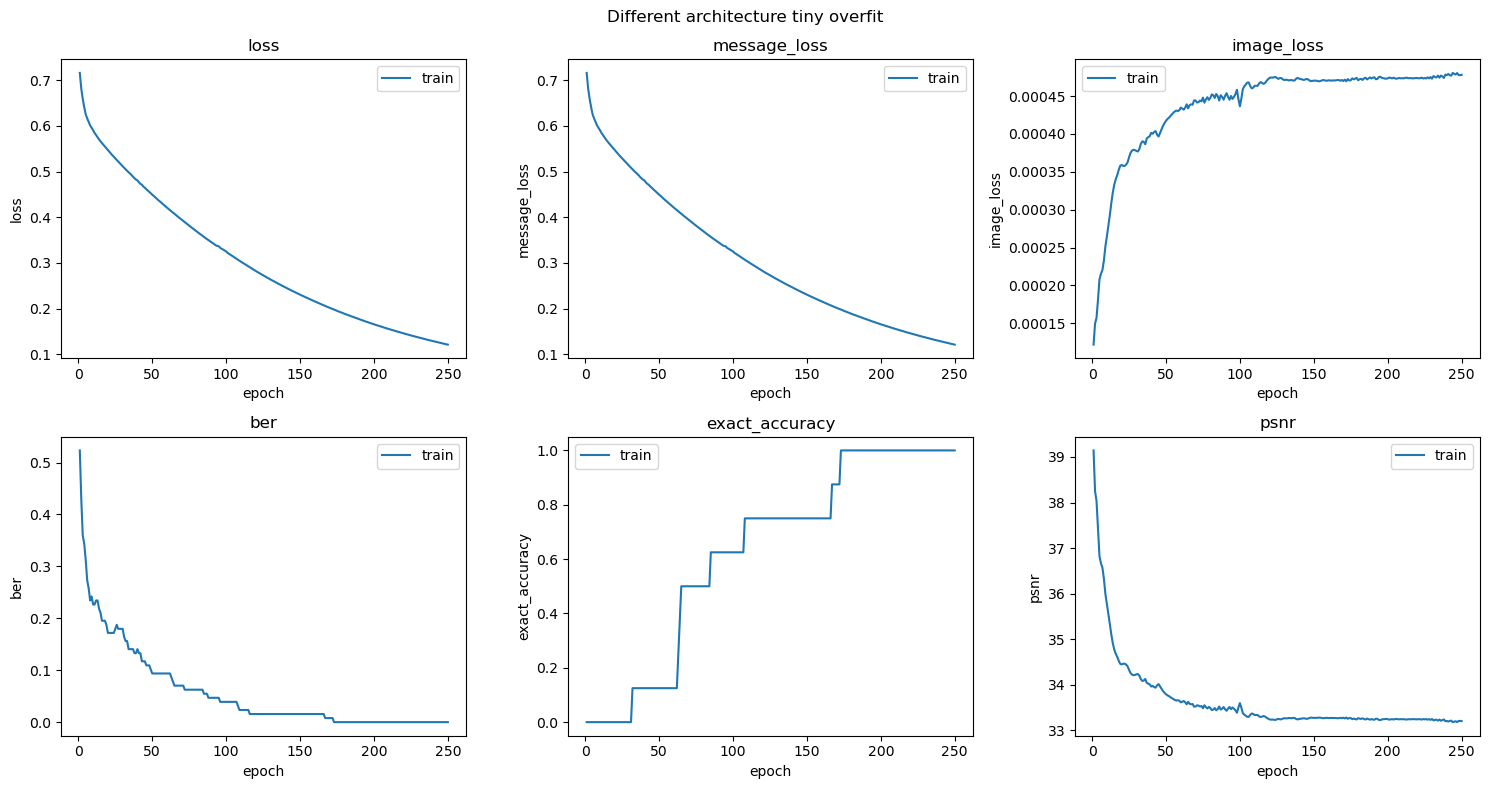

In [6]:
tiny_config = TrainConfig(
    experiment_name="different-architecture-tiny",
    epochs=250,
    batch_size=8,
    message_length=16,
    encoder_channels=40,
    decoder_channels=40,
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/different-architecture-tiny.csv",
    attack_configs=None,
    print_every=25,
)

clear_training_log(tiny_config.log_path)

with open(SMALL_SPLIT_FILE, "r") as f:
    n_train_images = len(json.load(f)["train"])

tiny_messages = torch.randint(
    0,
    2,
    (n_train_images, tiny_config.message_length),
    generator=torch.Generator().manual_seed(SEED),
    dtype=torch.float32,
)

tiny_train_loader, _, _ = get_dataloaders(
    DATA_DIR,
    SMALL_SPLIT_FILE,
    batch_size=tiny_config.batch_size,
    num_workers=0,
    shuffle_train=False,
)

tiny_encoder, tiny_decoder, tiny_history = fit(
    train_loader=tiny_train_loader,
    val_loader=tiny_train_loader,
    config=tiny_config,
    fixed_train_messages=tiny_messages,
    fixed_val_messages=tiny_messages,
)

tiny_df = analyze_run(
    tiny_config.log_path,
    name="Different architecture tiny overfit",
    show_validation=False,
)

### Tiny-Set Results

The 16-bit model reaches training BER `0` and exact message accuracy `1` by epoch 175.

## Clean Training: Medium-Set Check

We proceed to one larger clean check. The next run uses 1,024 training images and 128 validation images, batch size 16, `max_delta=0.03`, and no noise or image-loss term. We first run 10 epochs and continue the same checkpoint to at most 20 only if validation BER clearly improves. This is a trend check, not final test-set evaluation.

Epoch 1/10 | train_loss=0.6916 | train_BER=0.4752 | train_exact=0.0000 | val_loss=0.6808 | val_BER=0.4473 | val_exact=0.0000 | val_PSNR=33.77 | 29.7s


Epoch 2/10 | train_loss=0.6769 | train_BER=0.4339 | train_exact=0.0010 | val_loss=0.6780 | val_BER=0.4263 | val_exact=0.0000 | val_PSNR=32.43 | 23.3s


Epoch 3/10 | train_loss=0.6720 | train_BER=0.4234 | train_exact=0.0000 | val_loss=0.6727 | val_BER=0.4092 | val_exact=0.0000 | val_PSNR=32.40 | 23.9s


Epoch 4/10 | train_loss=0.6701 | train_BER=0.4241 | train_exact=0.0000 | val_loss=0.6670 | val_BER=0.4082 | val_exact=0.0000 | val_PSNR=32.65 | 23.7s


Epoch 5/10 | train_loss=0.6674 | train_BER=0.4189 | train_exact=0.0000 | val_loss=0.6685 | val_BER=0.4204 | val_exact=0.0000 | val_PSNR=32.50 | 23.8s


Epoch 6/10 | train_loss=0.6621 | train_BER=0.4082 | train_exact=0.0000 | val_loss=0.6613 | val_BER=0.4097 | val_exact=0.0000 | val_PSNR=32.56 | 23.2s


Epoch 7/10 | train_loss=0.6580 | train_BER=0.3958 | train_exact=0.0000 | val_loss=0.6772 | val_BER=0.4150 | val_exact=0.0000 | val_PSNR=32.42 | 22.8s


Epoch 8/10 | train_loss=0.6543 | train_BER=0.3931 | train_exact=0.0000 | val_loss=0.6560 | val_BER=0.3931 | val_exact=0.0000 | val_PSNR=32.29 | 23.5s


Epoch 9/10 | train_loss=0.6563 | train_BER=0.3979 | train_exact=0.0000 | val_loss=0.6560 | val_BER=0.3940 | val_exact=0.0000 | val_PSNR=32.68 | 23.7s


Epoch 10/10 | train_loss=0.6524 | train_BER=0.3885 | train_exact=0.0000 | val_loss=0.6534 | val_BER=0.3896 | val_exact=0.0000 | val_PSNR=32.48 | 23.6s
Training time: 4.0 minutes
Summary for Different architecture medium clean check
-----------------------------------------------------
Epochs run: 10
Best result by val_loss: epoch 10
  train: loss=0.6524, BER=0.3885, exact_accuracy=0.0000, PSNR=32.70
  val: loss=0.6534, BER=0.3896, exact_accuracy=0.0000, PSNR=32.48
Last epoch:
  train: loss=0.6524, BER=0.3885, exact_accuracy=0.0000, PSNR=32.70
  val: loss=0.6534, BER=0.3896, exact_accuracy=0.0000, PSNR=32.48


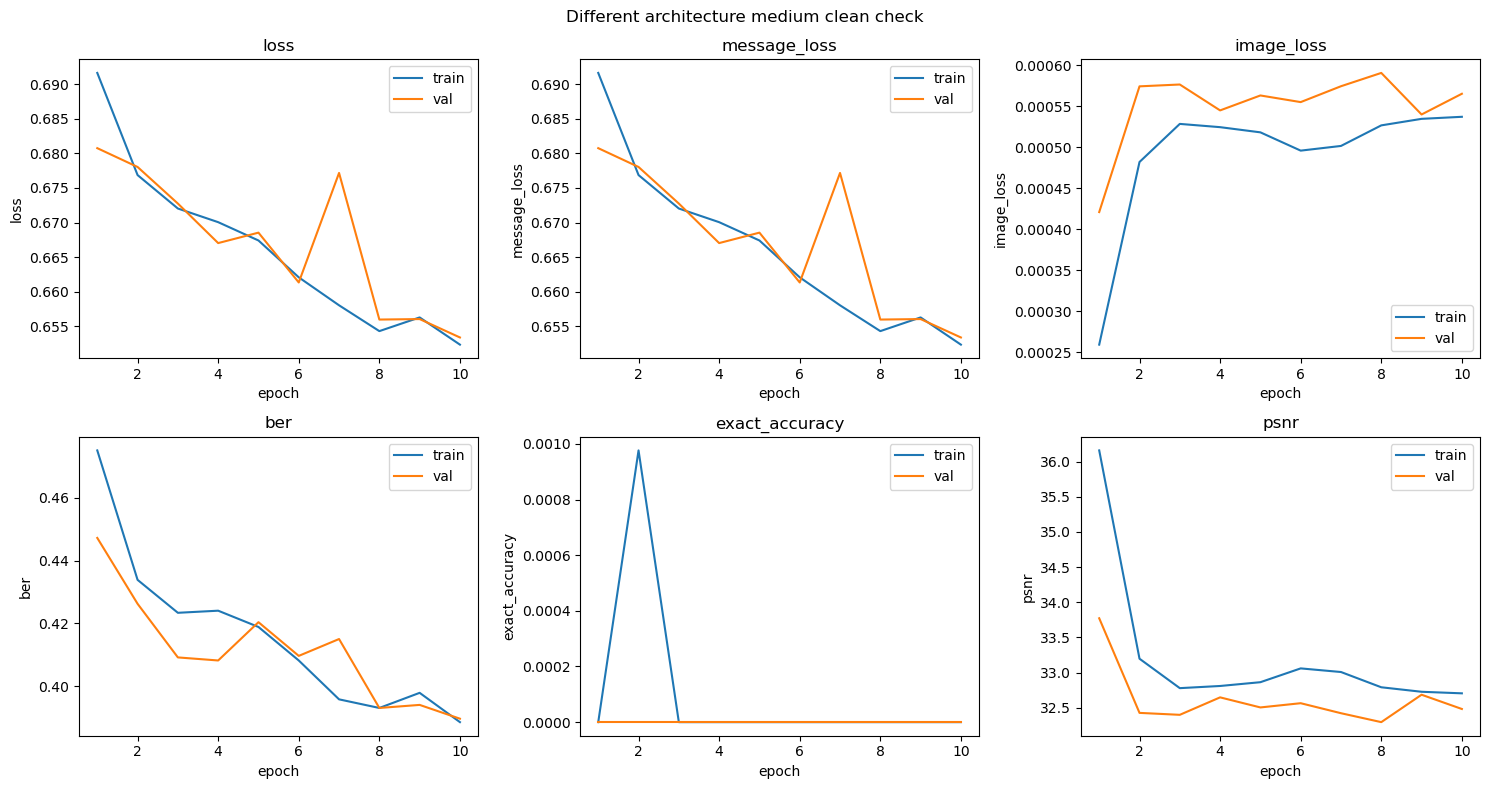

In [1]:
MEDIUM_SPLIT_FILE = make_subset_splits_file(
    SPLITS_FILE,
    Path("../results/splits/different-architecture-medium.json"),
    n_train=1024,
    n_val=128,
    n_test=0,
)

medium_config = TrainConfig(
    experiment_name="different-architecture-medium",
    epochs=10,
    batch_size=16,
    message_length=16,
    encoder_channels=40,
    decoder_channels=40,
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir="../results/checkpoints",
    log_path="../results/logs/different-architecture-medium.csv",
    attack_configs=None,
    print_every=1,
)

clear_training_log(medium_config.log_path)

medium_encoder, medium_decoder, medium_history = run_training(
    data_dir=DATA_DIR,
    splits_file=MEDIUM_SPLIT_FILE,
    config=medium_config,
    num_workers=4,
)

medium_df = analyze_run(
    medium_config.log_path,
    name="Different architecture medium clean check",
)

### Medium-Set Training Continuation

The first 10 epochs showed a decreasing validation BER, so the same checkpoint is continued to epoch 20. The table after training reads the complete CSV log, including epochs produced before this notebook cell was added.

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.train import TrainConfig, run_training

medium_config = TrainConfig(
    experiment_name="different-architecture-medium",
    epochs=20,
    batch_size=16,
    message_length=16,
    encoder_channels=40,
    decoder_channels=40,
    encoder_max_delta=0.03,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir=str(PROJECT_ROOT / "results" / "checkpoints"),
    log_path=str(PROJECT_ROOT / "results" / "logs" / "different-architecture-medium.csv"),
    attack_configs=None,
    print_every=1,
)

medium_checkpoint = (
    Path(medium_config.checkpoint_dir)
    / medium_config.experiment_name
    / "last.pt"
)

medium_encoder, medium_decoder, medium_continued_history = run_training(
    data_dir=PROJECT_ROOT / "data",
    splits_file=PROJECT_ROOT / "results" / "splits" / "different-architecture-medium.json",
    config=medium_config,
    num_workers=4,
    resume_from=medium_checkpoint,
)

medium_df = pd.read_csv(medium_config.log_path)
medium_df[[
    "epoch",
    "train_loss",
    "train_ber",
    "val_loss",
    "val_ber",
    "val_exact_accuracy",
    "val_psnr",
    "epoch_seconds",
]].round(4)

Epoch 15/20 | train_loss=0.6447 | train_BER=0.3807 | train_exact=0.0000 | val_loss=0.6370 | val_BER=0.3701 | val_exact=0.0000 | val_PSNR=32.17 | 22.3s
Epoch 16/20 | train_loss=0.6415 | train_BER=0.3754 | train_exact=0.0000 | val_loss=0.6432 | val_BER=0.3716 | val_exact=0.0000 | val_PSNR=32.07 | 23.4s
Epoch 17/20 | train_loss=0.6392 | train_BER=0.3748 | train_exact=0.0000 | val_loss=0.6372 | val_BER=0.3657 | val_exact=0.0000 | val_PSNR=32.17 | 24.2s
Epoch 18/20 | train_loss=0.6380 | train_BER=0.3741 | train_exact=0.0000 | val_loss=0.6352 | val_BER=0.3726 | val_exact=0.0000 | val_PSNR=32.22 | 25.5s
Epoch 19/20 | train_loss=0.6356 | train_BER=0.3707 | train_exact=0.0000 | val_loss=0.6291 | val_BER=0.3667 | val_exact=0.0000 | val_PSNR=32.06 | 25.4s
Epoch 20/20 | train_loss=0.6333 | train_BER=0.3695 | train_exact=0.0000 | val_loss=0.6807 | val_BER=0.3921 | val_exact=0.0000 | val_PSNR=32.15 | 25.0s
Training time: 2.4 minutes


,epoch,train_loss,train_ber,val_loss,val_ber,val_exact_accuracy,val_psnr,epoch_seconds
0,1,0.6916,0.4752,0.6808,0.4473,0.0,33.7719,29.7057
1,2,0.6769,0.4339,0.6780,0.4263,0.0,32.4265,23.2922
2,3,0.6720,0.4234,0.6727,0.4092,0.0,32.3989,23.9232
3,4,0.6701,0.4241,0.6670,0.4082,0.0,32.6472,23.6786
4,5,0.6674,0.4189,0.6685,0.4204,0.0,32.5039,23.7941
5,6,0.6621,0.4082,0.6613,0.4097,0.0,32.5641,23.2480
6,7,0.6580,0.3958,0.6772,0.4150,0.0,32.4218,22.8332
7,8,0.6543,0.3931,0.6560,0.3931,0.0,32.2949,23.5434
8,9,0.6563,0.3979,0.6560,0.3940,0.0,32.6846,23.7131
9,10,0.6524,0.3885,0.6534,0.3896,0.0,32.4820,23.6161


### Medium-Set Results

The 20-epoch run takes 9.2 minutes in total. Validation BER improves from `0.4473` at epoch 1 to a best value of `0.3657` at epoch 17. At epoch 19, which has the lowest validation loss, BER is `0.3667`, exact message accuracy is `0`, and PSNR is `32.06` dB.

## Clean Training: Full Dataset

After the medium check, the same 40-channel model is trained on the complete training split. The run resumes from the medium checkpoint and continues through epoch 200.

Configuration:

- 4,000 training and 500 validation images;
- 500 test images remained unused;
- 16-bit messages, batch size 16;
- Adam with learning rate `1e-3`;
- `max_delta=0.03`;
- no noise attacks and no image-loss term;
- fixed validation messages with seed 95;
- the best checkpoint was selected by validation BER.

Unfortunately, the training wasn't done in the notebook. The cells below load the preserved CSV log and checkpoint.

In [ ]:
RUN_FULL_CLEAN = False

if RUN_FULL_CLEAN:
    full_clean_config = TrainConfig(
        experiment_name="different-architecture-full-clean",
        epochs=200,
        batch_size=16,
        message_length=16,
        encoder_channels=40,
        decoder_channels=40,
        encoder_max_delta=0.03,
        learning_rate=1e-3,
        image_loss_weight=0.0,
        device="cuda",
        checkpoint_dir=str(PROJECT_ROOT / "results" / "checkpoints"),
        log_path=str(
            PROJECT_ROOT
            / "results"
            / "logs"
            / "different-architecture-full-clean.csv"
        ),
        attack_configs=None,
        print_every=1,
        checkpoint_metric="ber",
        target_val_ber=None,
    )

    full_clean_last_checkpoint = (
        Path(full_clean_config.checkpoint_dir)
        / full_clean_config.experiment_name
        / "last.pt"
    )
    medium_best_checkpoint = (
        PROJECT_ROOT
        / "results"
        / "checkpoints"
        / "different-architecture-medium"
        / "best_model.pt"
    )
    full_clean_resume_from = (
        full_clean_last_checkpoint
        if full_clean_last_checkpoint.exists()
        else medium_best_checkpoint
    )

    print(f"Resuming from: {full_clean_resume_from}")
    run_training(
        data_dir=PROJECT_ROOT / "data",
        splits_file=PROJECT_ROOT / "data" / "splits.json",
        config=full_clean_config,
        num_workers=4,
        resume_from=full_clean_resume_from,
    )

In [3]:
from IPython.display import display

RESULTS_DIR = Path("../results").resolve()
CLEAN_LOG_PATH = RESULTS_DIR / "logs" / "different-architecture-full-clean.csv"
CLEAN_CHECKPOINT_PATH = (
    RESULTS_DIR
    / "checkpoints"
    / "different-architecture-full-clean"
    / "best_model.pt"
)

clean_log = pd.read_csv(CLEAN_LOG_PATH)
clean_checkpoint = torch.load(
    CLEAN_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
 )
clean_best = clean_log.loc[clean_log["val_ber"].idxmin()]

clean_configuration = pd.DataFrame(
    [
        {
            "train_images": 4000,
            "validation_images": 500,
            "test_images_used": 0,
            "message_bits": clean_checkpoint["config"]["message_length"],
            "batch_size": clean_checkpoint["config"]["batch_size"],
            "learning_rate": clean_checkpoint["config"]["learning_rate"],
            "max_delta": clean_checkpoint["config"]["encoder_max_delta"],
            "encoder_channels": clean_checkpoint["config"]["encoder_channels"],
            "decoder_channels": clean_checkpoint["config"]["decoder_channels"],
            "checkpoint_metric": clean_checkpoint["config"]["checkpoint_metric"],
        }
    ]
)

milestone_epochs = [20, 40, 60, 80, 100, 120, 140, 160, 180, 195, 200]
clean_milestones = clean_log[
    clean_log["epoch"].isin(milestone_epochs)
][
    [
        "epoch",
        "train_loss",
        "train_ber",
        "train_exact_accuracy",
        "val_loss",
        "val_ber",
        "val_exact_accuracy",
        "val_psnr",
    ]
]

display(clean_configuration)
display(clean_milestones.round(6))
print(
    f"Best checkpoint: epoch {int(clean_best['epoch'])}, "
    f"validation BER={clean_best['val_ber']:.6f}, "
    f"exact accuracy={clean_best['val_exact_accuracy']:.3f}, "
    f"PSNR={clean_best['val_psnr']:.2f} dB"
 )

,train_images,validation_images,test_images_used,message_bits,batch_size,learning_rate,max_delta,encoder_channels,decoder_channels,checkpoint_metric
0,4000,500,0,16,16,0.001,0.03,40,40,ber


,epoch,train_loss,train_ber,train_exact_accuracy,val_loss,val_ber,val_exact_accuracy,val_psnr
0,20,0.628849,0.367859,0.00025,0.645494,0.389625,0.000,32.208459
20,40,0.354286,0.179328,0.02825,0.343746,0.178375,0.042,34.813690
40,60,0.239208,0.129344,0.07625,0.226789,0.126750,0.084,34.626412
60,80,0.148067,0.068594,0.25200,0.123455,0.059000,0.308,34.020420
80,100,0.115764,0.061250,0.30450,0.100636,0.052250,0.370,34.573163
100,120,0.111740,0.060031,0.31475,0.089350,0.052500,0.344,34.446490
120,140,0.067111,0.030562,0.59125,0.053102,0.022250,0.664,34.270982
140,160,0.028528,0.008375,0.89150,0.013218,0.002750,0.964,34.306161
160,180,0.021300,0.006391,0.91775,0.007338,0.001500,0.978,34.446476
175,195,0.019921,0.005969,0.92150,0.003460,0.000125,0.998,34.489788


Best checkpoint: epoch 195, validation BER=0.000125, exact accuracy=0.998, PSNR=34.49 dB


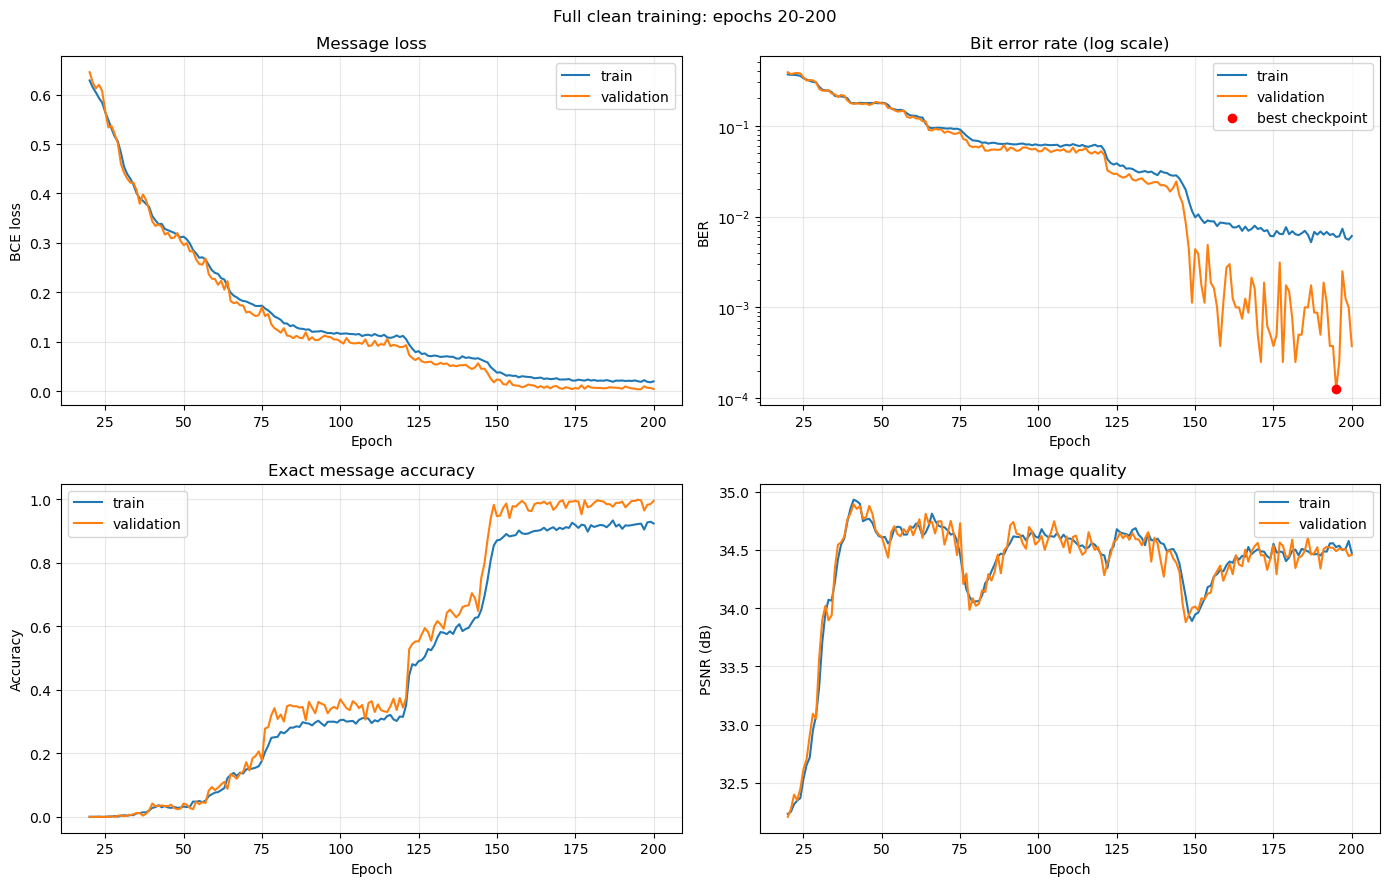

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(clean_log["epoch"], clean_log["train_loss"], label="train")
axes[0, 0].plot(clean_log["epoch"], clean_log["val_loss"], label="validation")
axes[0, 0].set_title("Message loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE loss")

axes[0, 1].plot(clean_log["epoch"], clean_log["train_ber"], label="train")
axes[0, 1].plot(clean_log["epoch"], clean_log["val_ber"], label="validation")
axes[0, 1].scatter(
    [clean_best["epoch"]],
    [clean_best["val_ber"]],
    color="red",
    label="best checkpoint",
    zorder=3,
 )
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Bit error rate (log scale)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("BER")

axes[1, 0].plot(
    clean_log["epoch"],
    clean_log["train_exact_accuracy"],
    label="train",
 )
axes[1, 0].plot(
    clean_log["epoch"],
    clean_log["val_exact_accuracy"],
    label="validation",
 )
axes[1, 0].set_title("Exact message accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")

axes[1, 1].plot(clean_log["epoch"], clean_log["train_psnr"], label="train")
axes[1, 1].plot(clean_log["epoch"], clean_log["val_psnr"], label="validation")
axes[1, 1].set_title("Image quality")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("PSNR (dB)")

for axis in axes.flat:
    axis.grid(alpha=0.3)
    axis.legend()

fig.suptitle("Full clean training: epochs 20-200")
fig.tight_layout()
plt.show()

### Full-Dataset Results

The clean model converged after a long stable improvement rather than after an architectural or hyperparameter grid search. The best checkpoint is epoch 195:

- validation BER: `0.000125` (1 incorrect bit out of 8,000);
- exact message accuracy: `0.998` (499 of 500 messages fully correct);
- validation PSNR: `34.49 dB`;

Validation metrics closely follow or outperform training metrics, so the result does not show a train-validation generalization gap.

## Robust Training: Methodology

Clean training taught the model to hide and read messages without additional changes to the watermarked image. We now continue training with attacks: changes such as noise, blur, resizing or rotation. The goal is to recover the same message even after the image has been changed.

We introduce these changes in two stages:

- **Mild phase:** train with small changes to the images, starting from the best clean checkpoint.
- **Hard phase:** if the mild phase is not enough, add stronger changes while keeping the mild ones. This stage starts from the best mild checkpoint.

Both the encoder and decoder continue learning in these stages. Each stage saves checkpoints in a separate folder, so the original clean checkpoint remains unchanged.

For each training batch, we randomly choose one attack between encoding and decoding. The attacks are differentiable, so we can calculate how changes in the encoder affect the decoding error after the attack. We also include an identity option, meaning no attack. Following the HiDDeN approach, each batch receives one option rather than all attacks at once.

Validation uses the same attack schedule in every epoch. We shuffle the list with seed `95`, then cycle through it across batches. In the mild phase, each option receives four or five of the 32 validation batches. After validation, we restore the random-number generator states so it does not change the randomness of subsequent training.

Rotation also rotates the content mask to keep it aligned with the image. Noise, blur and downscale/restore leave the mask unchanged. We select checkpoints by validation BER, then evaluate the selected model under each attack separately to identify its remaining weaknesses.

### Clean-Model Attack Baseline

Before training with attacks, we check how well the best clean model can read messages from distorted images. Each attack is evaluated separately on the same 500 validation images with the same fixed 16-bit messages. Model weights stay unchanged during these checks. These results are our baseline: the starting point for judging whether robust training helps.

BER and exact message accuracy measure how well the message is recovered after the attack. PSNR compares the original image with the watermarked image before the attack, so it measures the change caused by embedding the message, not by the attack.

The next cell loads and displays these saved results; it does not run the model again.

,scenario,ber,exact_accuracy,message_loss,psnr
0,clean,0.000125,0.998,0.003460,34.489788
1,noise-0.01,0.001000,0.988,0.005500,34.489788
2,noise-0.03,0.072375,0.268,0.335039,34.489788
3,noise-0.05,0.182875,0.032,1.509004,34.489788
4,blur-3-0.5,0.076375,0.210,0.313196,34.489788
5,blur-5-1.0,0.469375,0.000,0.702067,34.489788
6,downscale-0.75,0.370375,0.002,0.679707,34.489788
7,downscale-0.50,0.496750,0.000,0.709963,34.489788
8,rotation-minus-2,0.078875,0.208,0.281072,34.489788
9,rotation-plus-2,0.083500,0.198,0.278624,34.489788


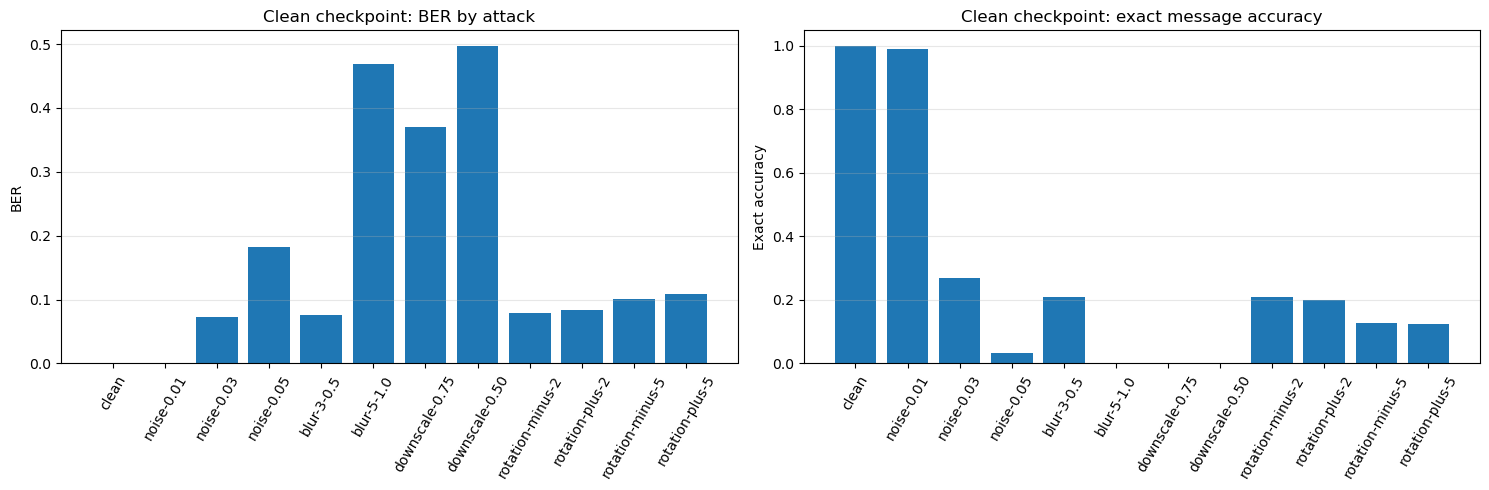

In [5]:
CLEAN_ATTACK_PROFILE_PATH = RESULTS_DIR / "logs" / "clean-attack-baseline.csv"
clean_attack_profile = pd.read_csv(CLEAN_ATTACK_PROFILE_PATH)

display(
    clean_attack_profile[
        ["scenario", "ber", "exact_accuracy", "message_loss", "psnr"]
    ].round(6)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(clean_attack_profile["scenario"], clean_attack_profile["ber"])
axes[0].set_title("Clean checkpoint: BER by attack")
axes[0].set_ylabel("BER")
axes[0].tick_params(axis="x", rotation=60)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    clean_attack_profile["scenario"],
    clean_attack_profile["exact_accuracy"],
 )
axes[1].set_title("Clean checkpoint: exact message accuracy")
axes[1].set_ylabel("Exact accuracy")
axes[1].tick_params(axis="x", rotation=60)
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

## Robust Training: Mild Attacks

The mild phase starts from the best clean checkpoint and runs for 40 epochs with learning rate `3e-4`. The encoder residual remains bounded by `max_delta=0.03`. Each training batch receives one of:

- identity;
- Gaussian noise with standard deviation `0.01` or `0.03`;
- Gaussian blur with kernel `3` and sigma `0.5`;
- downscale/restore with factor `0.75`;
- rotation by `-2` or `+2` degrees.

An initial five-epoch pilot used a fixed random validation sample and was discarded after detecting unequal attack representation. The reported run below uses the balanced deterministic validation protocol.

,epochs,best_epoch,learning_rate,mixed_validation_ber,mixed_exact_accuracy,validation_psnr
0,40,21,0.0003,0.045125,0.774,34.067725


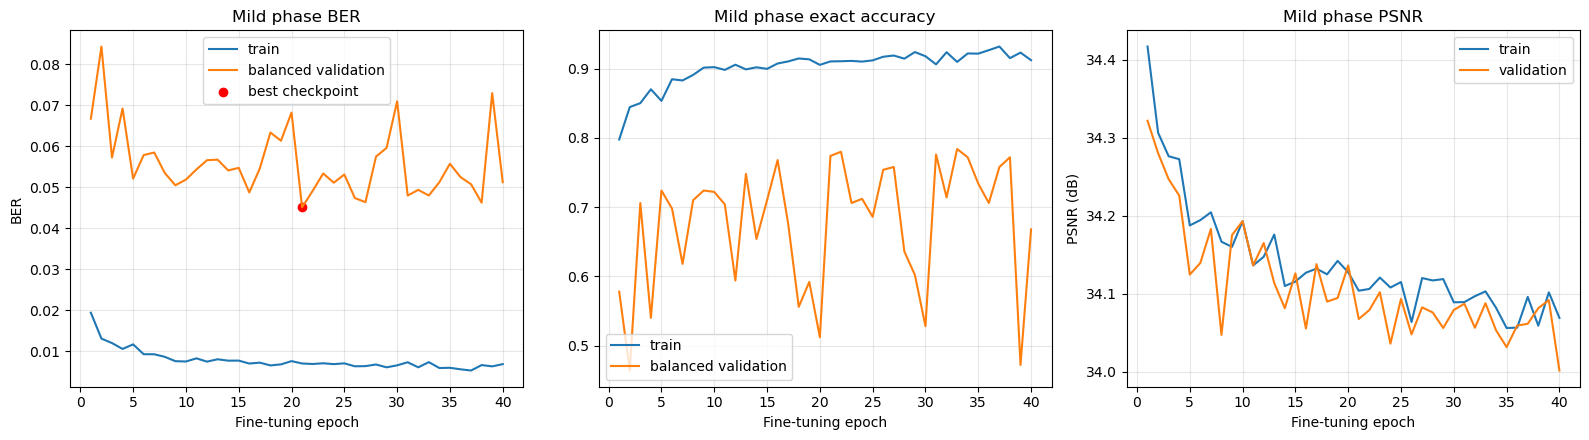

In [6]:
MILD_LOG_PATH = RESULTS_DIR / "logs" / "robust-mild-balanced.csv"
MILD_SCENARIO_PATH = (
    RESULTS_DIR / "logs" / "robust-mild-balanced-scenarios.csv"
)

mild_log = pd.read_csv(MILD_LOG_PATH)
mild_scenarios = pd.read_csv(MILD_SCENARIO_PATH)
mild_best = mild_log.loc[mild_log["val_ber"].idxmin()]

mild_summary = pd.DataFrame(
    [
        {
            "epochs": len(mild_log),
            "best_epoch": int(mild_best["epoch"]),
            "learning_rate": float(mild_best["learning_rate"]),
            "mixed_validation_ber": float(mild_best["val_ber"]),
            "mixed_exact_accuracy": float(mild_best["val_exact_accuracy"]),
            "validation_psnr": float(mild_best["val_psnr"]),
        }
    ]
)
display(mild_summary.round(6))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(mild_log["epoch"], mild_log["train_ber"], label="train")
axes[0].plot(mild_log["epoch"], mild_log["val_ber"], label="balanced validation")
axes[0].scatter(
    [mild_best["epoch"]],
    [mild_best["val_ber"]],
    color="red",
    label="best checkpoint",
 )
axes[0].set_title("Mild phase BER")
axes[0].set_xlabel("Fine-tuning epoch")
axes[0].set_ylabel("BER")

axes[1].plot(
    mild_log["epoch"],
    mild_log["train_exact_accuracy"],
    label="train",
 )
axes[1].plot(
    mild_log["epoch"],
    mild_log["val_exact_accuracy"],
    label="balanced validation",
 )
axes[1].set_title("Mild phase exact accuracy")
axes[1].set_xlabel("Fine-tuning epoch")

axes[2].plot(mild_log["epoch"], mild_log["train_psnr"], label="train")
axes[2].plot(mild_log["epoch"], mild_log["val_psnr"], label="validation")
axes[2].set_title("Mild phase PSNR")
axes[2].set_xlabel("Fine-tuning epoch")
axes[2].set_ylabel("PSNR (dB)")

for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()

fig.tight_layout()
plt.show()

,scenario,ber_clean_model,exact_accuracy_clean_model,ber_mild_model,exact_accuracy_mild_model,ber_reduction
0,clean,0.000125,0.998,0.006250,0.910,-0.006125
1,noise-0.01,0.001000,0.988,0.005750,0.920,-0.004750
2,noise-0.03,0.072375,0.268,0.030500,0.632,0.041875
3,noise-0.05,0.182875,0.032,0.120250,0.080,0.062625
4,blur-3-0.5,0.076375,0.210,0.002625,0.958,0.073750
5,blur-5-1.0,0.469375,0.000,0.477250,0.000,-0.007875
6,downscale-0.75,0.370375,0.002,0.308125,0.004,0.062250
7,downscale-0.50,0.496750,0.000,0.497500,0.000,-0.000750
8,rotation-minus-2,0.078875,0.208,0.006250,0.902,0.072625
9,rotation-plus-2,0.083500,0.198,0.002375,0.964,0.081125


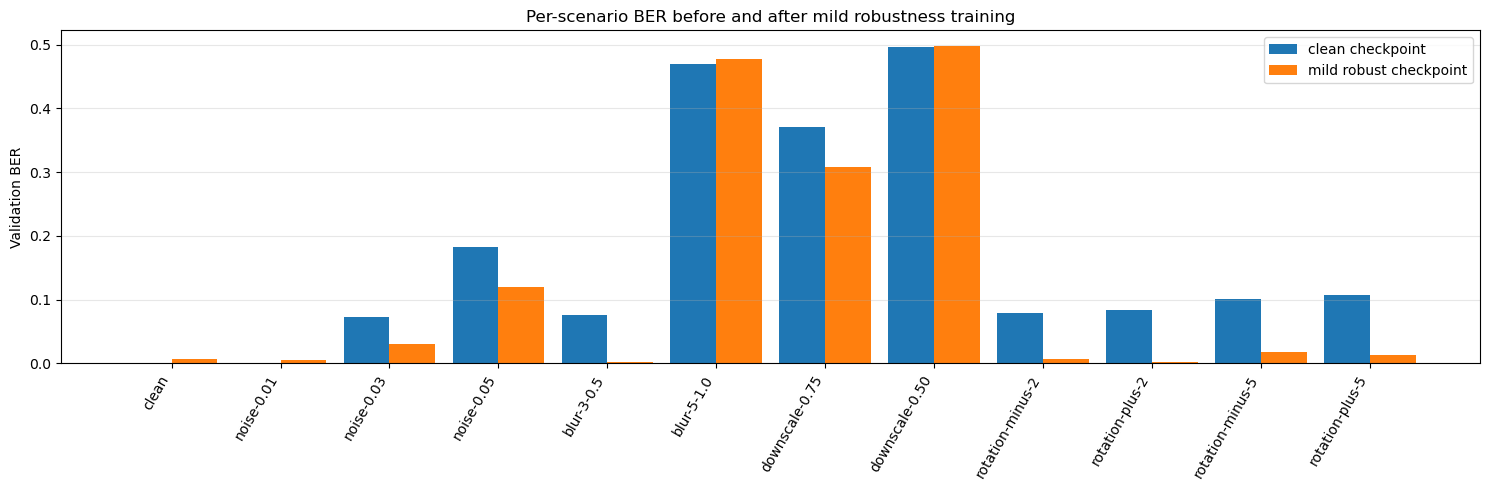

In [7]:
scenario_comparison = clean_attack_profile[
    ["scenario", "ber", "exact_accuracy"]
] .merge(
    mild_scenarios[["scenario", "ber", "exact_accuracy"]],
    on="scenario",
    suffixes=("_clean_model", "_mild_model"),
)
scenario_comparison["ber_reduction"] = (
    scenario_comparison["ber_clean_model"]
    - scenario_comparison["ber_mild_model"]
)

display(scenario_comparison.round(6))

positions = range(len(scenario_comparison))
bar_width = 0.42
fig, axis = plt.subplots(figsize=(15, 5))
axis.bar(
    [position - bar_width / 2 for position in positions],
    scenario_comparison["ber_clean_model"],
    width=bar_width,
    label="clean checkpoint",
 )
axis.bar(
    [position + bar_width / 2 for position in positions],
    scenario_comparison["ber_mild_model"],
    width=bar_width,
    label="mild robust checkpoint",
 )
axis.set_xticks(list(positions))
axis.set_xticklabels(scenario_comparison["scenario"], rotation=60, ha="right")
axis.set_ylabel("Validation BER")
axis.set_title("Per-scenario BER before and after mild robustness training")
axis.grid(axis="y", alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()

### Mild-Attack Results

Of the 40 training epochs, epoch 21 has the lowest validation BER on the balanced mix of mild attacks. At this checkpoint, BER is `0.045125` (about `4.51%` of bits are incorrect), and `77.4%` of messages are read completely correctly. PSNR before attacks is `34.07 dB`. Validation results fluctuate, so we keep the best checkpoint rather than the last one.

The comparison under the same attacks shows improvements for Gaussian noise with `std=0.03` and `0.05`, mild blur and rotations. However, this improvement comes at a cost: on images without attacks, exact message accuracy drops from `99.8%` to `91.0%`. Performance also worsens under the lightest noise (`std=0.01`).

Strong `5x5` blur and downscale/restore remain major weaknesses, with roughly half the bits decoded incorrectly under strong blur or downscaling to half size. The robustness targets are therefore not met. We continue from the best mild checkpoint with stronger attacks in the hard training phase.

## Robust Training: Hard Attacks

The hard phase starts from the best mild checkpoint and uses learning rate `1e-4` for 60 epochs. It retains all mild configurations and additionally samples:

- Gaussian noise with standard deviation `0.05`;
- Gaussian blur with kernel `5` and sigma `1.0`;
- downscale/restore with factor `0.5`;
- rotation by `-5` or `+5` degrees.

A balanced deterministic validation schedule represents all 12 hard-phase configurations. The next cell resumes from the latest hard checkpoint. Its epoch output is the authoritative live training record in this notebook.

In [8]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.train import TrainConfig, run_training

MILD_ATTACKS = [
    {"name": "none"},
    {"name": "gaussian_noise", "std": 0.01},
    {"name": "gaussian_noise", "std": 0.03},
    {"name": "gaussian_blur", "kernel_size": 3, "sigma": 0.5},
    {"name": "downscale", "scale_factor": 0.75},
    {"name": "rotation", "angle": -2.0},
    {"name": "rotation", "angle": 2.0},
]
HARD_ATTACKS = MILD_ATTACKS + [
    {"name": "gaussian_noise", "std": 0.05},
    {"name": "gaussian_blur", "kernel_size": 5, "sigma": 1.0},
    {"name": "downscale", "scale_factor": 0.5},
    {"name": "rotation", "angle": -5.0},
    {"name": "rotation", "angle": 5.0},
]

hard_config = TrainConfig(
    experiment_name="different-architecture-robust-hard-balanced",
    epochs=60,
    batch_size=16,
    message_length=16,
    encoder_channels=40,
    decoder_channels=40,
    encoder_max_delta=0.03,
    learning_rate=1e-4,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir=str(PROJECT_ROOT / "results" / "checkpoints"),
    log_path=str(
        PROJECT_ROOT / "results" / "logs" / "robust-hard-balanced.csv"
    ),
    attack_configs=HARD_ATTACKS,
    validation_attack_configs=HARD_ATTACKS,
    print_every=1,
    checkpoint_metric="ber",
)

hard_checkpoint = (
    Path(hard_config.checkpoint_dir)
    / hard_config.experiment_name
    / "last.pt"
)
print(f"Resuming hard training from: {hard_checkpoint}")

hard_encoder, hard_decoder, hard_continued_history = run_training(
    data_dir=PROJECT_ROOT / "data",
    splits_file=PROJECT_ROOT / "data" / "splits.json",
    config=hard_config,
    num_workers=4,
    resume_from=hard_checkpoint,
)

Resuming hard training from: C:\Users\kalu\OneDrive\Desktop\MU\DeepImageWatermarking\results\checkpoints\different-architecture-robust-hard-balanced\last.pt
Epoch 20/60 | train_loss=0.0468 | train_BER=0.0164 | train_exact=0.8295 | val_loss=0.2458 | val_BER=0.1064 | val_exact=0.5560 | val_PSNR=33.82 | 60.3s
Epoch 21/60 | train_loss=0.0454 | train_BER=0.0155 | train_exact=0.8320 | val_loss=0.2246 | val_BER=0.1126 | val_exact=0.5520 | val_PSNR=33.78 | 60.5s
Epoch 22/60 | train_loss=0.0443 | train_BER=0.0148 | train_exact=0.8400 | val_loss=0.2339 | val_BER=0.1086 | val_exact=0.5900 | val_PSNR=33.78 | 59.4s
Epoch 23/60 | train_loss=0.0463 | train_BER=0.0157 | train_exact=0.8380 | val_loss=0.2515 | val_BER=0.1128 | val_exact=0.5360 | val_PSNR=33.76 | 58.3s
Epoch 24/60 | train_loss=0.0514 | train_BER=0.0179 | train_exact=0.8085 | val_loss=0.2165 | val_BER=0.1089 | val_exact=0.5960 | val_PSNR=33.76 | 62.6s
Epoch 25/60 | train_loss=0.0534 | train_BER=0.0191 | train_exact=0.8037 | val_loss=0.220

### Hard-Attack Validation

After hard training finishes, the next cell evaluates the selected hard checkpoint independently on all 12 scenarios. This per-scenario table is more interpretable than the balanced mixed-attack metric used for checkpoint selection.

The robustness target is:

- clean BER below `0.01`;
- average attacked BER below `0.05`;
- worst attacked BER below `0.15`.

The test split remains untouched. It will be evaluated exactly once only after this validation analysis locks the final checkpoint and attack configuration.

clean: BER=0.0170, exact=0.7560, PSNR=33.63
noise-0.01: BER=0.0181, exact=0.7400, PSNR=33.63
noise-0.03: BER=0.0554, exact=0.3840, PSNR=33.63
noise-0.05: BER=0.1633, exact=0.0280, PSNR=33.63
blur-3-0.5: BER=0.0004, exact=0.9940, PSNR=33.63
blur-5-1.0: BER=0.3769, exact=0.0020, PSNR=33.63
downscale-0.75: BER=0.1569, exact=0.0600, PSNR=33.63
downscale-0.50: BER=0.4770, exact=0.0000, PSNR=33.63
rotation-minus-2: BER=0.0025, exact=0.9620, PSNR=33.63
rotation-plus-2: BER=0.0006, exact=0.9920, PSNR=33.63
rotation-minus-5: BER=0.0109, exact=0.8300, PSNR=33.63
rotation-plus-5: BER=0.0032, exact=0.9500, PSNR=33.63


,scenario,ber,exact_accuracy,message_loss,psnr
0,clean,0.017000,0.756,0.045814,33.625981
1,noise-0.01,0.018125,0.740,0.048086,33.625981
2,noise-0.03,0.055375,0.384,0.156880,33.625981
3,noise-0.05,0.163250,0.028,0.935200,33.625981
4,blur-3-0.5,0.000375,0.994,0.004237,33.625981
5,blur-5-1.0,0.376875,0.002,0.623137,33.625981
6,downscale-0.75,0.156875,0.060,0.380269,33.625981
7,downscale-0.50,0.477000,0.000,0.700732,33.625981
8,rotation-minus-2,0.002500,0.962,0.009901,33.625981
9,rotation-plus-2,0.000625,0.992,0.006274,33.625981


Average attacked BER: 0.1150
Worst attacked BER: 0.4770


,clean_ber,average_attacked_ber,worst_attacked_ber,target_reached
0,0.017,0.115011,0.477,False


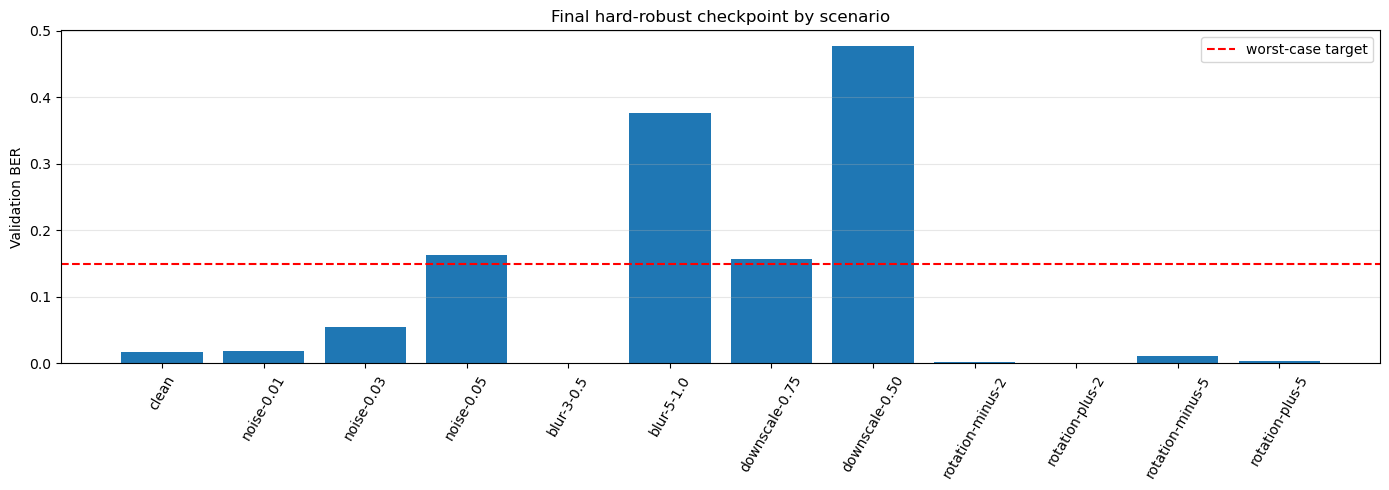

In [9]:
RESULTS_SCRIPTS_DIR = PROJECT_ROOT / "results"
sys.path.append(str(RESULTS_SCRIPTS_DIR))

from run_robust_pipeline import evaluate_checkpoint, robust_target_reached

hard_best_checkpoint = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "different-architecture-robust-hard-balanced"
    / "best_model.pt"
)
hard_scenario_path = (
    PROJECT_ROOT
    / "results"
    / "logs"
    / "robust-hard-balanced-scenarios.csv"
)

hard_scenario_records = evaluate_checkpoint(
    hard_best_checkpoint,
    hard_scenario_path,
)
hard_scenario_results = pd.DataFrame(hard_scenario_records)
display(
    hard_scenario_results[
        ["scenario", "ber", "exact_accuracy", "message_loss", "psnr"]
    ].round(6)
)

attacked_results = hard_scenario_results[
    hard_scenario_results["scenario"] != "clean"
]
average_attacked_ber = attacked_results["ber"].mean()
worst_attacked_ber = attacked_results["ber"].max()
clean_ber = hard_scenario_results.loc[
    hard_scenario_results["scenario"] == "clean",
    "ber",
] .iloc[0]

summary = pd.DataFrame(
    [
        {
            "clean_ber": clean_ber,
            "average_attacked_ber": average_attacked_ber,
            "worst_attacked_ber": worst_attacked_ber,
            "target_reached": robust_target_reached(hard_scenario_records),
        }
    ]
)
display(summary.round(6))

fig, axis = plt.subplots(figsize=(14, 5))
axis.bar(hard_scenario_results["scenario"], hard_scenario_results["ber"])
axis.axhline(0.15, color="red", linestyle="--", label="worst-case target")
axis.set_ylabel("Validation BER")
axis.set_title("Final hard-robust checkpoint by scenario")
axis.tick_params(axis="x", rotation=60)
axis.grid(axis="y", alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()

### BatchNorm Diagnostics

Hard training uses one attack per batch. In training mode, BatchNorm normalizes each batch with statistics specific to that attack. During evaluation, it instead uses a single set of running statistics accumulated across clean, noise, blur, downscale, and rotation batches.

The next diagnostic keeps model weights fixed and compares standard evaluation with BatchNorm layers temporarily using current-batch statistics. It is not a deployable evaluation mode and is not used for model selection. A large improvement would indicate that mixed BatchNorm statistics, rather than insufficient convolutional capacity alone, are limiting robustness.

In [11]:
from torch import nn

from src.data import get_dataloaders
from src.evaluate import load_models
from src.message_metrics import logits_to_bits
from src.noise import apply_attack

_, diagnostic_val_loader, _ = get_dataloaders(
    PROJECT_ROOT / "data",
    PROJECT_ROOT / "data" / "splits.json",
    batch_size=16,
    num_workers=4,
    shuffle_train=False,
)
diagnostic_messages = torch.randint(
    0,
    2,
    (len(diagnostic_val_loader.dataset), 16),
    generator=torch.Generator().manual_seed(SEED),
    dtype=torch.float32,
)

diagnostic_scenarios = {
    "clean": [],
    "noise-0.05": [{"name": "gaussian_noise", "std": 0.05}],
    "blur-5-1.0": [
        {"name": "gaussian_blur", "kernel_size": 5, "sigma": 1.0}
    ],
    "downscale-0.75": [{"name": "downscale", "scale_factor": 0.75}],
    "downscale-0.50": [{"name": "downscale", "scale_factor": 0.5}],
}


@torch.no_grad()
def evaluate_with_batchnorm_batch_stats(checkpoint_path, attacks):
    device = torch.device("cuda")
    encoder, decoder, _ = load_models(checkpoint_path, device)

    for model in (encoder, decoder):
        model.eval()
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.train()
                module.momentum = 0.0

    bit_errors = 0
    exact_messages = 0
    message_start = 0

    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    for images, masks in diagnostic_val_loader:
        images = images.to(device)
        masks = masks.to(device)
        batch_size = images.size(0)
        message_end = message_start + batch_size
        messages = diagnostic_messages[message_start:message_end].to(device)
        message_start = message_end

        watermarked = encoder(images, messages, masks)
        decoder_input = watermarked
        decoder_masks = masks
        for attack in attacks:
            decoder_input, decoder_masks = apply_attack(
                decoder_input,
                decoder_masks,
                attack,
            )

        predicted = logits_to_bits(decoder(decoder_input, decoder_masks))
        targets = messages.bool()
        bit_errors += (predicted != targets).sum().item()
        exact_messages += (predicted == targets).all(dim=1).sum().item()

    num_images = len(diagnostic_val_loader.dataset)
    return {
        "batch_stats_ber": bit_errors / (num_images * 16),
        "batch_stats_exact_accuracy": exact_messages / num_images,
    }


batch_stats_records = []
for scenario, attacks in diagnostic_scenarios.items():
    metrics = evaluate_with_batchnorm_batch_stats(
        hard_best_checkpoint,
        attacks,
    )
    batch_stats_records.append({"scenario": scenario, **metrics})

batch_stats_results = pd.DataFrame(batch_stats_records)
batchnorm_comparison = hard_scenario_results[
    hard_scenario_results["scenario"].isin(diagnostic_scenarios)
]["scenario ber exact_accuracy".split()].merge(
    batch_stats_results,
    on="scenario",
)
display(batchnorm_comparison.round(6))

,scenario,ber,exact_accuracy,batch_stats_ber,batch_stats_exact_accuracy
0,clean,0.017000,0.756,0.007625,0.890
1,noise-0.05,0.163250,0.028,0.012250,0.854
2,blur-5-1.0,0.376875,0.002,0.013375,0.834
3,downscale-0.75,0.156875,0.060,0.010000,0.870
4,downscale-0.50,0.477000,0.000,0.046000,0.486


## Robust Training: Fused Decoder

The BatchNorm diagnostic shows that decoding improves when the models use current-batch statistics. We now test whether a decoder without BatchNorm can retain useful watermark features without depending on running statistics or on the other images in a batch.

We start from the hard checkpoint and fuse each decoder `Conv+BatchNorm` pair into an equivalent convolution in evaluation mode. This preserves its evaluation behavior at initialization, up to numerical rounding. The encoder is then frozen, and only the decoder is fine-tuned.

This phase runs for 20 epochs with learning rate `3e-4` on the same hard-attack set and balanced validation schedule. It uses a separate experiment directory, so the clean, mild and hard checkpoints remain unchanged.

In [18]:
import importlib

import src.decoder as decoder_module
import src.evaluate as evaluate_module
import src.train as train_module

importlib.reload(decoder_module)
importlib.reload(train_module)
importlib.reload(evaluate_module)

from src.decoder import WatermarkDecoder
from src.train import TrainConfig, run_training, save_checkpoint

fused_config = TrainConfig(
    experiment_name="different-architecture-robust-fused-decoder",
    epochs=20,
    batch_size=16,
    message_length=16,
    encoder_channels=40,
    decoder_channels=40,
    decoder_normalization="none",
    freeze_encoder=True,
    encoder_max_delta=0.03,
    learning_rate=3e-4,
    image_loss_weight=0.0,
    device="cuda",
    checkpoint_dir=str(PROJECT_ROOT / "results" / "checkpoints"),
    log_path=str(
        PROJECT_ROOT / "results" / "logs" / "robust-fused-decoder.csv"
    ),
    attack_configs=HARD_ATTACKS,
    validation_attack_configs=HARD_ATTACKS,
    print_every=1,
    checkpoint_metric="ber",
)

fused_checkpoint_dir = (
    Path(fused_config.checkpoint_dir) / fused_config.experiment_name
)
fused_initial_checkpoint = fused_checkpoint_dir / "initial.pt"
fused_last_checkpoint = fused_checkpoint_dir / "last.pt"

if fused_last_checkpoint.exists():
    fused_resume_from = fused_last_checkpoint
else:
    source = torch.load(
        hard_best_checkpoint,
        map_location="cpu",
        weights_only=False,
    )

    fused_encoder = WatermarkEncoder(
        message_length=16,
        feature_channels=40,
        max_delta=0.03,
    )
    fused_encoder.load_state_dict(source["encoder_state_dict"])
    fused_encoder.requires_grad_(False)

    fused_decoder = WatermarkDecoder(
        message_length=16,
        feature_channels=40,
        normalization="batch",
    )
    fused_decoder.load_state_dict(source["decoder_state_dict"])
    fused_decoder.eval()
    fused_decoder.fuse_batch_norm()

    fused_optimizer = torch.optim.Adam(
        fused_decoder.parameters(),
        lr=fused_config.learning_rate,
    )
    fused_log_path = Path(fused_config.log_path)
    if fused_log_path.exists():
        fused_log_path.unlink()
    save_checkpoint(
        fused_initial_checkpoint,
        fused_encoder,
        fused_decoder,
        fused_optimizer,
        epoch=-1,
        best_val_loss=float("inf"),
        config=fused_config,
    )
    fused_resume_from = fused_initial_checkpoint

print(f"Resuming fused decoder training from: {fused_resume_from}")
fused_encoder, fused_decoder, fused_history = run_training(
    data_dir=PROJECT_ROOT / "data",
    splits_file=PROJECT_ROOT / "data" / "splits.json",
    config=fused_config,
    num_workers=4,
    resume_from=fused_resume_from,
)

Resuming fused decoder training from: C:\Users\kalu\OneDrive\Desktop\MU\DeepImageWatermarking\results\checkpoints\different-architecture-robust-fused-decoder\initial.pt
Epoch 1/20 | train_loss=0.1830 | train_BER=0.0842 | train_exact=0.5978 | val_loss=0.1055 | val_BER=0.0512 | val_exact=0.7340 | val_PSNR=33.63 | 52.6s
Epoch 2/20 | train_loss=0.1309 | train_BER=0.0637 | train_exact=0.6820 | val_loss=0.1111 | val_BER=0.0488 | val_exact=0.6400 | val_PSNR=33.63 | 53.1s
Epoch 3/20 | train_loss=0.1299 | train_BER=0.0546 | train_exact=0.6607 | val_loss=0.1314 | val_BER=0.0629 | val_exact=0.6160 | val_PSNR=33.63 | 8149.2s
Epoch 4/20 | train_loss=0.1172 | train_BER=0.0523 | train_exact=0.6613 | val_loss=0.0915 | val_BER=0.0374 | val_exact=0.6980 | val_PSNR=33.63 | 49.8s
Epoch 5/20 | train_loss=0.1063 | train_BER=0.0452 | train_exact=0.6997 | val_loss=0.0574 | val_BER=0.0229 | val_exact=0.8160 | val_PSNR=33.63 | 51.1s
Epoch 6/20 | train_loss=0.0730 | train_BER=0.0294 | train_exact=0.7640 | val_lo

### Fused-Decoder Validation

The balanced mixed-attack metric selects epoch 16. The next cell evaluates that checkpoint independently on every scenario and compares it with the BatchNorm hard checkpoint.

This comparison determines whether removing decoder running statistics solved the attack-domain shift and which attacks, if any, still require targeted fine-tuning.

clean: BER=0.0009, exact=0.9880, PSNR=33.63
noise-0.01: BER=0.0014, exact=0.9820, PSNR=33.63
noise-0.03: BER=0.0029, exact=0.9640, PSNR=33.63
noise-0.05: BER=0.0138, exact=0.8180, PSNR=33.63
blur-3-0.5: BER=0.0006, exact=0.9900, PSNR=33.63
blur-5-1.0: BER=0.0423, exact=0.4780, PSNR=33.63
downscale-0.75: BER=0.0110, exact=0.8440, PSNR=33.63
downscale-0.50: BER=0.1199, exact=0.1280, PSNR=33.63
rotation-minus-2: BER=0.0020, exact=0.9700, PSNR=33.63
rotation-plus-2: BER=0.0009, exact=0.9880, PSNR=33.63
rotation-minus-5: BER=0.0079, exact=0.8800, PSNR=33.63
rotation-plus-5: BER=0.0019, exact=0.9740, PSNR=33.63


,scenario,ber_batch_norm,exact_accuracy_batch_norm,ber_fused_decoder,exact_accuracy_fused_decoder,ber_reduction
0,clean,0.017000,0.756,0.000875,0.988,0.016125
1,noise-0.01,0.018125,0.740,0.001375,0.982,0.016750
2,noise-0.03,0.055375,0.384,0.002875,0.964,0.052500
3,noise-0.05,0.163250,0.028,0.013750,0.818,0.149500
4,blur-3-0.5,0.000375,0.994,0.000625,0.990,-0.000250
5,blur-5-1.0,0.376875,0.002,0.042250,0.478,0.334625
6,downscale-0.75,0.156875,0.060,0.011000,0.844,0.145875
7,downscale-0.50,0.477000,0.000,0.119875,0.128,0.357125
8,rotation-minus-2,0.002500,0.962,0.002000,0.970,0.000500
9,rotation-plus-2,0.000625,0.992,0.000875,0.988,-0.000250


,clean_ber,average_attacked_ber,worst_attacked_ber,worst_scenario
0,0.000875,0.01858,0.119875,downscale-0.50


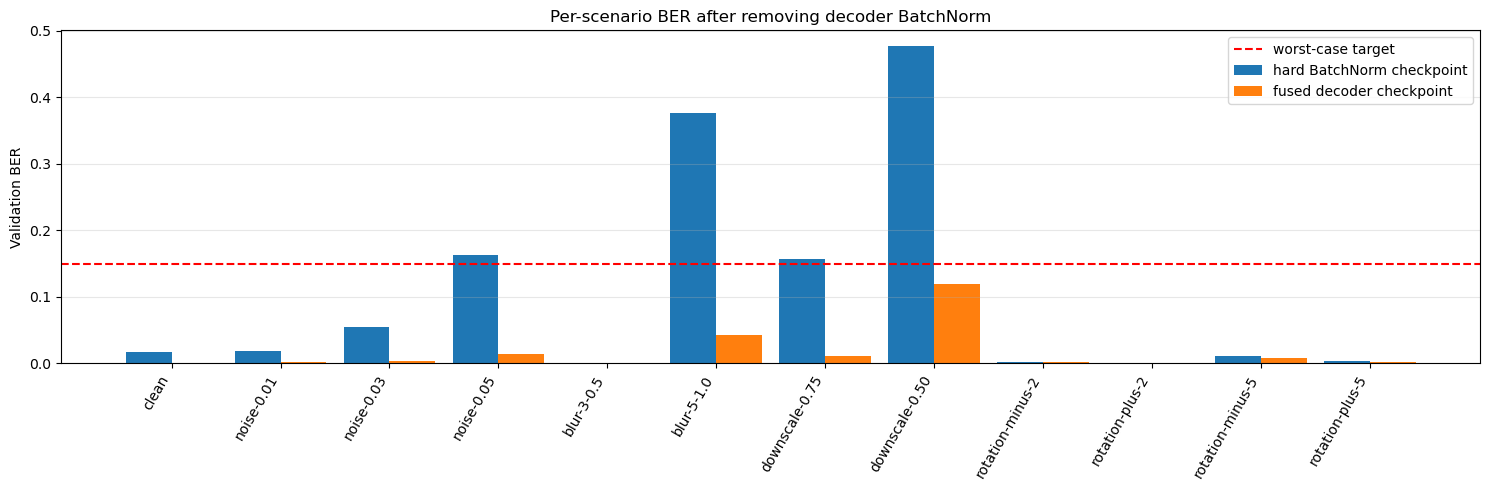

In [20]:
import importlib
import run_robust_pipeline as robust_pipeline_module

importlib.reload(robust_pipeline_module)
evaluate_checkpoint = robust_pipeline_module.evaluate_checkpoint

fused_best_checkpoint = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "different-architecture-robust-fused-decoder"
    / "best_model.pt"
)
fused_scenario_path = (
    PROJECT_ROOT
    / "results"
    / "logs"
    / "robust-fused-decoder-scenarios.csv"
)

fused_scenario_records = evaluate_checkpoint(
    fused_best_checkpoint,
    fused_scenario_path,
)
fused_scenario_results = pd.DataFrame(fused_scenario_records)

fused_comparison = hard_scenario_results[
    ["scenario", "ber", "exact_accuracy"]
] .merge(
    fused_scenario_results[["scenario", "ber", "exact_accuracy"]],
    on="scenario",
    suffixes=("_batch_norm", "_fused_decoder"),
)
fused_comparison["ber_reduction"] = (
    fused_comparison["ber_batch_norm"]
    - fused_comparison["ber_fused_decoder"]
)
display(fused_comparison.round(6))

fused_attacked = fused_scenario_results[
    fused_scenario_results["scenario"] != "clean"
]
fused_summary = pd.DataFrame(
    [
        {
            "clean_ber": fused_scenario_results.loc[
                fused_scenario_results["scenario"] == "clean",
                "ber",
            ].iloc[0],
            "average_attacked_ber": fused_attacked["ber"].mean(),
            "worst_attacked_ber": fused_attacked["ber"].max(),
            "worst_scenario": fused_attacked.loc[
                fused_attacked["ber"].idxmax(),
                "scenario",
            ],
        }
    ]
)
display(fused_summary.round(6))

positions = range(len(fused_comparison))
bar_width = 0.42
fig, axis = plt.subplots(figsize=(15, 5))
axis.bar(
    [position - bar_width / 2 for position in positions],
    fused_comparison["ber_batch_norm"],
    width=bar_width,
    label="hard BatchNorm checkpoint",
 )
axis.bar(
    [position + bar_width / 2 for position in positions],
    fused_comparison["ber_fused_decoder"],
    width=bar_width,
    label="fused decoder checkpoint",
 )
axis.axhline(0.15, color="red", linestyle="--", label="worst-case target")
axis.set_xticks(list(positions))
axis.set_xticklabels(fused_comparison["scenario"], rotation=60, ha="right")
axis.set_ylabel("Validation BER")
axis.set_title("Per-scenario BER after removing decoder BatchNorm")
axis.grid(axis="y", alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()

## Final Conclusion

Clean training showed that the model can recover 16-bit messages accurately from unchanged images. Attack training and decoder fine-tuning then improved recovery from modified images, while keeping encoded-image PSNR at about `33.63 dB`.

We choose the encoder from hard-attack training and the fused decoder, fine-tuned with the encoder frozen. On validation, the selected checkpoint achieves clean BER `0.000875`, average attacked BER `0.018580`, and worst-case BER `0.119875`, meeting all three targets.

The main limitation is downscaling to half size: only `12.8%` of complete messages are recovered in that scenario. Low average bit error therefore does not guarantee reliable recovery of every message.

The model and checkpoint are now fixed. The saved test results and their analysis are in the evaluation notebook.